### Phase 1: Structural demand and elasticity validation

In this phase, we focus on validating whether the simulated environment produces economically consistent and statistically identifiable demand behavior. Building on the exploratory analysis, the objective is to ensure that the underlying demand function can be reliably learned from data, particularly with respect to price elasticity and key market drivers.

This phase therefore emphasizes isolating the core economic relationships embedded in the simulation. Specifically, we aim to verify that:
- Demand responds negatively and nonlinearly to price;
- Price elasticity behaves consistently across different demand regimes;
- Seasonal effects shift demand levels in a stable and learnable manner;
- The system remains identifiable when excluding redundant or state-driven features.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [2]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])

df["rel_price"] = np.clip(np.log(df["price_competitor"]) - np.log(df["price_agent"]), -0.8, 0.8)
df["competitor_lag_1"] = df["price_competitor"].shift(1)
df["rel_price_lag_1"] = df["rel_price"].shift(1)
df["price_lag_1"] = df["price_agent"].shift(1)
df["lag_1"] = df["realized_demand"].shift(1)

df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(90, 12)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,price_lag_1,lag_1
85,2025-03-28,134.345831,178.076805,0.000338,-0.057332,186.916376,8342.630120,0.281798,168.972300,0.221468,135.404554,62.166373
86,2025-03-29,147.954683,175.893300,0.000176,0.011256,114.686989,7594.025603,0.172972,178.076805,0.281798,134.345831,186.916376
87,2025-03-30,107.184015,167.187601,0.000089,-0.302732,79.644643,5337.627740,0.444569,175.893300,0.172972,147.954683,114.686989
88,2025-03-31,125.116498,168.511787,0.000044,0.039753,195.373472,8987.674718,0.297760,167.187601,0.444569,107.184015,79.644643
89,2025-04-01,146.459285,168.414978,1.126515,0.184123,267.082808,22891.788640,0.139684,168.511787,0.297760,125.116498,195.373472


In [3]:
df[["realized_demand", "price_agent", "price_competitor", "rel_price",
    "season_signal", "lag_1", "price_lag_1", "competitor_lag_1",
    "rel_price_lag_1"]].corr()

,realized_demand,price_agent,price_competitor,rel_price,season_signal,lag_1,price_lag_1,competitor_lag_1,rel_price_lag_1
realized_demand,1.000000,0.074801,-0.175973,-0.188913,0.635889,0.440775,-0.038852,-0.217119,-0.187497
price_agent,0.074801,1.000000,-0.022760,-0.514774,0.063856,0.038061,0.015159,-0.032601,-0.047190
price_competitor,-0.175973,-0.022760,1.000000,0.864813,-0.212938,-0.194132,-0.057936,0.944920,0.821552
rel_price,-0.188913,-0.514774,0.864813,1.000000,-0.205362,-0.183215,-0.054357,0.816171,0.721167
season_signal,0.635889,0.063856,-0.212938,-0.205362,1.000000,0.554608,0.068159,-0.225284,-0.218951
lag_1,0.440775,0.038061,-0.194132,-0.183215,0.554608,1.000000,0.060067,-0.204316,-0.203902
price_lag_1,-0.038852,0.015159,-0.057936,-0.054357,0.068159,0.060067,1.000000,-0.043558,-0.530132
competitor_lag_1,-0.217119,-0.032601,0.944920,0.816171,-0.225284,-0.204316,-0.043558,1.000000,0.866106
rel_price_lag_1,-0.187497,-0.047190,0.821552,0.721167,-0.218951,-0.203902,-0.530132,0.866106,1.000000


The correlation structure highlights several important relationships. Seasonality shows the strongest positive correlation with demand (~0.64), followed by lag (~0.44), confirming that both capture significant variation in baseline demand and persistence effects.

Agent price exhibits a near-zero correlation with demand (~0.07), suggesting that its effect is not easily captured through simple linear relationships and requires nonlinear modeling.

Relative price and competitor price are highly correlated with each other (~0.86), indicating strong multicollinearity and suggesting that they encode similar competitive information. Both show weak negative correlations with demand, reflecting substitution effects but with limited standalone explanatory power.

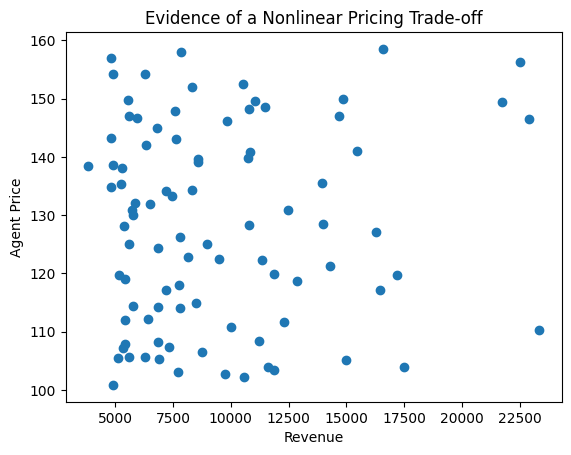

In [4]:
plt.scatter(df["revenue"], df["price_agent"])
plt.xlabel("Revenue")
plt.ylabel("Agent Price")
plt.title("Evidence of a Nonlinear Pricing Trade-off")
plt.show()

The scatter plot illustrates the relationship between agent price and resulting revenue, highlighting a clear nonlinear trade-off. Revenue does not increase monotonically with price; instead, similar revenue levels are observed across a wide range of prices. This reflects the fundamental balance between price and demand: higher prices increase margin but reduce demand, while lower prices boost demand but compress margins.

The dispersion of points suggests the presence of an implicit optimal pricing region rather than a single optimal price. In some cases, relatively lower prices achieve comparable or even higher revenues than higher prices, indicating that demand responsiveness plays a critical role.

C:\Users\Breno\AppData\Local\Temp\ipykernel_18876\2534809518.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_effect = df.groupby(bins)["revenue"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_18876\2534809518.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_effect = df.groupby(bins)["price_agent"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_18876\2534809518.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(price_effect.values.astype(np.int16))


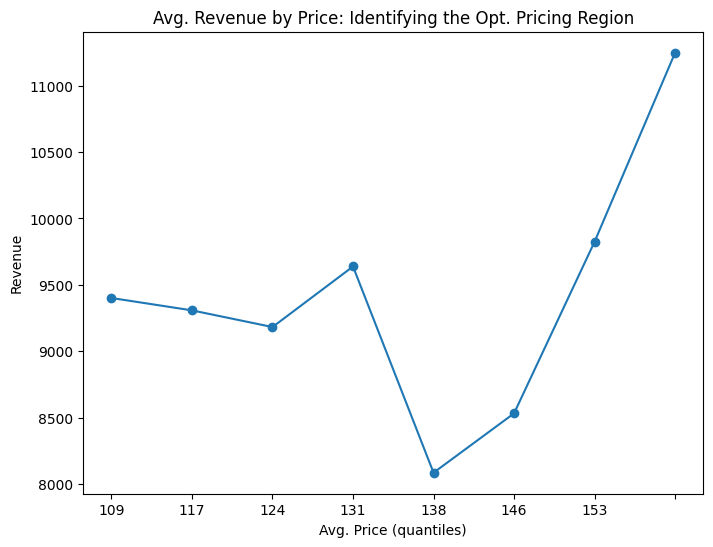

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = pd.qcut(df["price_agent"], 8)
rev_effect = df.groupby(bins)["revenue"].mean()
price_effect = df.groupby(bins)["price_agent"].mean()

ax.set_xticklabels(price_effect.values.astype(np.int16))

plt.plot(rev_effect.values, marker="o")
plt.title("Revenue vs Price")
plt.xlabel("Avg. Price (quantiles)")
plt.ylabel("Revenue")

plt.title("Avg. Revenue by Price: Identifying the Opt. Pricing Region")
plt.show()

This plot shows the average revenue achieved at different price levels, revealing a clear nonlinear relationship. Revenue initially declines as price increases, suggesting that demand reduction outweighs margin gains in this range. However, beyond a certain point, revenue begins to recover and eventually increases, indicating that higher margins start compensating for lower demand.

The dip around the mid-price range highlights a suboptimal pricing region, while the upward trend at higher prices suggests the presence of a more profitable pricing zone. This pattern reflects the interaction between price elasticity and margin, where optimal pricing is not linear but depends on balancing demand sensitivity with per-unit profitability.

In [6]:

df["log_demand"] = np.log(df["realized_demand"])
y = df["log_demand"].values

X = df[["price_agent", "price_competitor", "season_signal"]].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearGAM(
    s(0, constraints='monotonic_dec') + # price_agent
    s(1) + # price_competitor
    s(2) #+ # season_signal
    #s(3) + # relative price
   # s(4)   # Lag 1
).fit(X, y)

model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     18.2959
Link Function:                     IdentityLink Log Likelihood:                                   -37.5999
Number of Samples:                           90 AIC:                                              113.7916
                                                AICc:                                             125.0284
                                                GCV:                                                0.2576
                                                Scale:                                              0.4068
                                                Pseudo R-Squared:                                   0.5544
Feature Function                  Lam

C:\Users\Breno\AppData\Local\Temp\ipykernel_18876\1534471654.py:18: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  model.summary()


The GAM results indicate that the model is capturing meaningful structure in the simulated demand. Agent price shows a strong and statistically significant nonlinear effect, confirming that the demand function is now identifiable and responsive to pricing decisions. Seasonality is also highly significant, suggesting that the simulated seasonal signal is consistent and learnable from the data.

On the other hand, competitor price appears only weakly significant. This is likely due to its construction as a persistent, state-dependent variable, which introduces correlation with other features and reduces its independent explanatory power in the model.

The overall model fit (pseudo R² ≈ 0.55) is moderate, reflecting a balance between explanatory power and interpretability. Notably, the removal of lagged variables reduced predictive performance but improved the ability to isolate causal drivers such as price and seasonality.

Finally, it is important to note that p-values in GAMs (especially in pyGAM) should be interpreted with caution due to smoothing parameter estimation. Therefore, significance is better assessed through a combination of statistical output, partial dependence analysis, and economic consistency of the learned relationships.

In [7]:
def partial_dependence_plot(idx, feature_name):
    XX = model.generate_X_grid(term=idx)
    pdp = model.partial_dependence(term=idx, X=XX)

    plt.plot(XX[:, idx], pdp)
    plt.xlabel(feature_name)
    plt.ylabel("Partial Effect on log(Demand)")
    plt.title(f"GAM Partial Dependence - {feature_name}")
    plt.show()

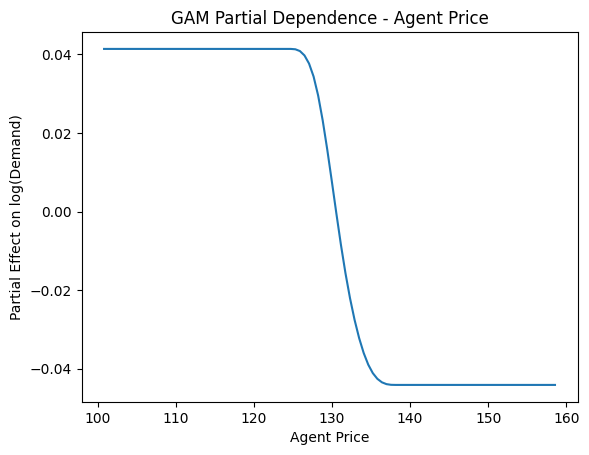

In [8]:
partial_dependence_plot(0, "Agent Price")

The partial dependence plot shows a clear nonlinear and monotonic decreasing relationship between price and demand. At lower price levels, the curve is relatively flat, indicating low sensitivity (inelastic demand). In the mid-price range (around 125–135), the curve becomes steep, suggesting a region of high elasticity where small price changes have a large impact on demand. At higher prices, the curve flattens again, reflecting demand saturation at low levels and reduced responsiveness to further price increases.

This pattern is consistent with a demand regime where consumers are less sensitive when prices are either very low (already attractive) or very high (demand already suppressed), with the strongest price sensitivity concentrated in intermediate price ranges.

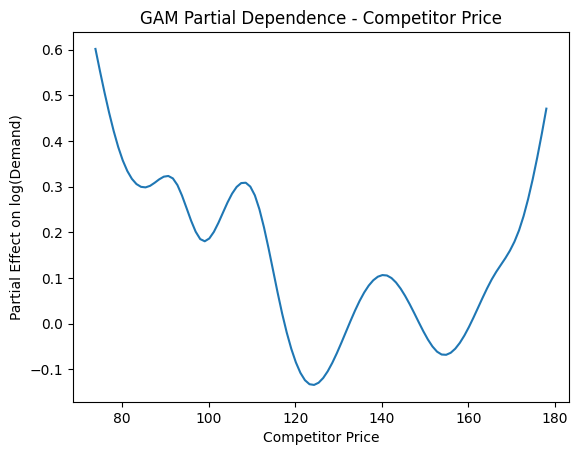

In [9]:
partial_dependence_plot(1, "Competitor Price")

The partial dependence plot suggests a generally positive but irregular relationship between competitor price and demand. Higher competitor prices tend to increase demand, consistent with substitution effects, although the relationship is noisy and non-monotonic. This reflects the weaker and less identifiable role of competitor pricing in the model, likely due to its persistence and correlation with other state variables. Overall, while the direction aligns with economic intuition, the effect appears less stable and less influential than the agent’s own price.

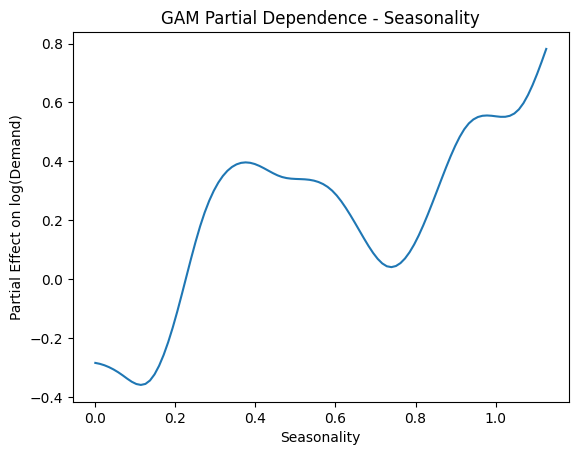

In [10]:
partial_dependence_plot(2, "Seasonality")

The partial dependence plot shows a clear positive relationship between seasonality and demand, with higher seasonal signals leading to increased demand. The effect is nonlinear, with moderate gains at mid-level seasonality and stronger increases at higher levels, reflecting peak demand periods. This indicates that seasonality is a consistent and well-identified driver in the model, capturing shifts in baseline demand rather than changes in price sensitivity.

#### EDA Conclusions

The exploratory analysis reveals that the simulated market environment captures realistic demand dynamics, with clear interactions between price, competition, seasonality, and temporal effects.

Price emerges as a key driver of demand, but its effect is inherently nonlinear. Both the GAM analysis and revenue curves show that demand is relatively inelastic at very low and very high price levels, with the strongest sensitivity concentrated in intermediate price ranges. This leads to a non-monotonic relationship between price and revenue, where optimal pricing lies within a specific region rather than at the extremes.

Seasonality is consistently identified as a strong and stable factor influencing demand. It primarily shifts the overall demand level rather than altering price sensitivity, reflecting realistic cyclical patterns such as demand peaks and troughs. Additionally, temporal dependence (lag effects) plays an important role, indicating persistence in demand and reinforcing the presence of underlying market regimes.

Competitive dynamics are present but less directly identifiable. Competitor price is highly correlated with other variables due to its state-dependent construction, which limits its standalone explanatory power. This highlights the importance of careful feature design when interpreting competitive effects.